# Debugging — Part 1: Fundamentals

> **Module:** 01 — Programming Best Practices  
> **Series:** Debugging in VS Code (1 of 3)  
> **Covers:** Breakpoints, the Variables panel, Step Over / Into / Out

---

## Why the Debugger Matters

Using `print()` to trace bugs is slow, incomplete, and leaves noise in the code.  
The VS Code debugger lets you **pause** anywhere, **inspect** every variable automatically, **step** through execution line by line, and **modify** state on the fly — all without touching a single line of source code.

> Throughout this series we use the file **`debug_example.py`** (in this same folder). Open it in VS Code alongside this notebook.

### Prerequisites

| Requirement | How to verify |
|---|---|
| Python Debugger extension (`ms-python.debugpy`) | Installed automatically with the Python extension |
| Python interpreter selected | `Ctrl+Shift+P` → **"Python: Select Interpreter"** — pick the desired version/environment |
| Debug panel | `Ctrl+Shift+D` opens the **Run and Debug** sidebar |


### Debug Toolbar — Quick Reference

| Button | Shortcut | Action |
|--------|----------|--------|
| ▶ Continue | `F5` | Resume until the next breakpoint |
| ⤳ Step Over | `F10` | Execute current line, skip into functions |
| ⤵ Step Into | `F11` | Enter the function called on this line |
| ⤴ Step Out | `Shift+F11` | Finish current function, return to caller |
| 🔄 Restart | `Ctrl+Shift+F5` | Restart the session from scratch |
| ⏹ Stop | `Shift+F5` | Stop debugging |

---

## 1 — Breakpoints

A **breakpoint** tells the debugger: *pause execution when you reach this line.*

### Setting a breakpoint

| Method | How |
|--------|-----|
| GUI | Click the **left margin** next to a line number |
| Keyboard | Place cursor on the line, press `F9` |

When the breakpoint is set, a red dot 🔴 appears.

### Starting a debug session

1. Open `debug_example.py`
2. Set a breakpoint on the line `total += numbers[i]` inside `calculate_average()`
3. Press `F5` — if there is no `launch.json` yet, VS Code asks what to debug: choose **"Python File"**
4. Execution runs normally until it hits the breakpoint, then **pauses**

At this point you have full control. The editor highlights the paused line and the debug toolbar appears at the top.

---

## 2 — The Variables Panel

When the debugger pauses, the **VARIABLES** panel (left sidebar) shows every variable in scope:

- **Locals** — variables in the current function (`total`, `i`, `numbers`)
- **Globals** — module-level names
- Compound objects (lists, dicts, DataFrames) can be expanded with the ▶ arrow
- Right-click a variable → **"Set Value"** to change it on the fly

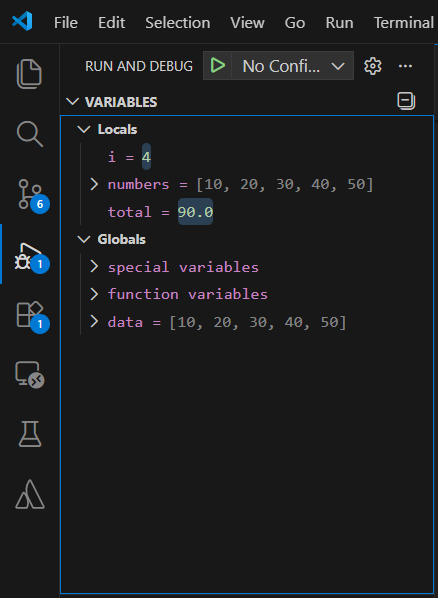

### Walkthrough — finding the off-by-one bug

With the debugger paused on `total += numbers[i]`:

1. Look at `i` in the Variables panel — it shows **1**, not 0. The first element (`numbers[0] = 10`) will never be added.
2. Press `F10` (Step Over) repeatedly. Watch `i` increment and `total` grow — but `total` starts from `numbers[1]`.
3. When the function returns, the result is **28.0** instead of the expected **30.0**.

The fix is obvious once you see it: `range(1, len(numbers))` should be `range(len(numbers))`.

### Hover inspection

While paused, **hover** over any variable in the editor to see its value in a tooltip.
This works for nested expressions too — hover over `numbers[i]` to see the element at the current index.

---

## 3 — Watch Expressions

The **WATCH** panel lets you track custom expressions that aren't stored in variables. They re-evaluate automatically every time the debugger pauses.

### How to add a Watch

1. In the Debug sidebar, find the **WATCH** section
2. Click the **+** button
3. Type any Python expression

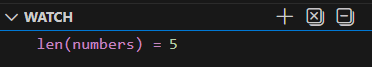

### Useful examples

Suppose we're stepping through a loop in `debug_example.py`:

| Watch expression | What it shows |
|-----------------|---------------|
| `len(numbers)` | Total list size (stays constant) |
| `total / (i + 1)` | Running average so far |
| `i == len(numbers) - 1` | `True` when we're at the last iteration |
| `numbers[i]` | Current element being processed |

Watches are especially powerful in loops — you see computed values evolve iteration by iteration without adding print statements.

---

## 4 — Step Over, Step Into, Step Out

Once the debugger is paused, you move through the code with three commands:

| Command | Shortcut | What happens |
|---------|----------|-------------|
| **Step Over** | `F10` | Executes the current line and moves to the next one. If the line contains a function call, the function runs **entirely** — you don't see its internals. |
| **Step Into** | `F11` | If the current line calls a function, **enters** it and pauses on its first line. If there's no function call, behaves like Step Over. |
| **Step Out** | `Shift+F11` | Runs the **rest** of the current function and pauses back in the caller, right after the line that called it. |

### How to choose

| Situation | Use |
|-----------|-----|
| You trust the function — just need to see what it returns | **Step Over** (`F10`) |
| You suspect the bug is inside the function | **Step Into** (`F11`) |
| You've already seen enough inside a function and want to go back | **Step Out** (`Shift+F11`) |



### Walkthrough

Open `debug_example.py` and set a breakpoint on `avg = calculate_average(data)` in the `__main__` block. Then:

1. **`F11`** — enters `calculate_average`. You can now see the loop from inside.
2. **`F10`** (several times) — steps through the loop one iteration at a time. Watch `total` and `i` change in the Variables panel.
3. **`Shift+F11`** — finishes `calculate_average` and returns to `__main__`, now on the next line (`profit = find_max_profit(...)`).

The pattern: **F11 to dive in, F10 to walk through, Shift+F11 to come back up.**

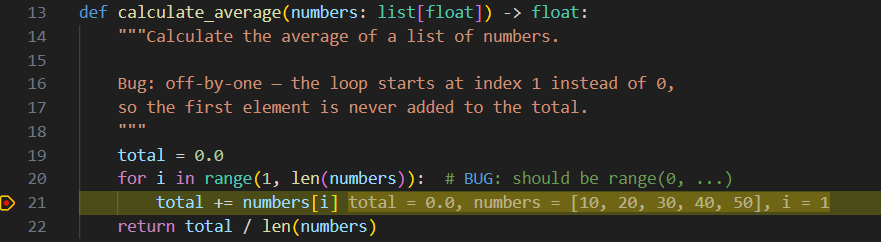

---

## Recap — Part 1

| Concept | Key takeaway |
|---------|-------------|
| **Breakpoints** | Click the gutter or press `F9`. The debugger pauses there. |
| **Variables panel** | Automatically shows all in-scope variables when paused. |
| **Watch expressions** | Custom expressions re-evaluated on every pause — great for loops. |
| **Step Over / Into / Out** | `F10` / `F11` / `Shift+F11` — the trio for navigating code. |

**Next →** [02_intermediate.ipynb](02_intermediate.ipynb) — Conditional breakpoints, logpoints, launch.json, and CLI argument debugging.